In [1]:
import matplotlib.pyplot as plt
import albumentations as A
from pathlib import Path
import yaml
import os
from collections import Counter
import pandas as pd
import random
import cv2
import matplotlib.patches as patches
import numpy as np
!pip3 install ultralytics
from ultralytics import YOLO



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 w

In [2]:
# Khi up lên kaggle nên cần cấu hình lên file yaml
yaml_content = """
path: /kaggle/input/datasets/lmgiathnh/final-dataset/final-dataset

train: train/images
val: val/images
test: 
    - test/Bright_Field/images
    - test/Dark_Field/images

nc: 5

names:
  - Broken
  - Chipped
  - Scratched
  - Severe_Rust
  - Tip_Wear
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("Đã tạo file data.yaml tại /kaggle/working/")


Đã tạo file data.yaml tại /kaggle/working/


# 1. Kiểm tra dữ liệu có số lượng dataset và tên classes

In [ ]:
# DATASET_PATH = Path("/Users/mac/Detect_Drill_Bit/final-dataset")
DATASET_PATH = Path("/kaggle/input/datasets/lmgiathnh/final-dataset/final-dataset")
DATA_YAML = "data.yaml"

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]

print(CLASS_NAMES)
print(NUM_CLASSES)

['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
5


# 2. Đếm dữ liệu cho từng bộ dữ liệu

In [4]:
def check_dataset():
    total_images = 0
    total_labels = 0
    for split in ["train", "val", "test/Bright_Field", "test/Dark_Field"]:
        img_path = DATASET_PATH / split / 'images'
        label_path = DATASET_PATH / split / 'labels'
        
        # glob dùng để tìm kiếm file, * là tìm kiếm tất cả, ? khớp với ký tự bất kỳ, [seq]: khớp với bất kỳ ký tự nào trong ngoặc vuông
        # suffix dùng để lấy đuôi file
        # đếm ảnh
        images = [f for f in img_path.glob("*") if f.suffix.lower() in [".jpg", ".png", ".png"]]
        num_images = print(f"images trong tập {split}", len(images))

        labels = list(label_path.glob("*.txt"))
        print(f"labels trong tập {split}", len(labels))        
        
        total_images += len(images)
        total_labels += len(labels)
    return total_images, total_labels

total_images, total_labels = check_dataset()
print("Tổng số lượng ảnh: ", total_images)
print("Tổng số lượng labels: ", total_labels)

images trong tập train 3521
labels trong tập train 3521
images trong tập val 744
labels trong tập val 744
images trong tập test/Bright_Field 292
labels trong tập test/Bright_Field 292
images trong tập test/Dark_Field 254
labels trong tập test/Dark_Field 254
Tổng số lượng ảnh:  4811
Tổng số lượng labels:  4811


# 3. Phân tích labels

In [5]:
def analyze_labels():
    class_counts = Counter()
    total_boxes = 0
    total_labels = 0

    for split in ["train", "val", "test/Bright_Field", "test/Dark_Field"]:
        label_path = DATASET_PATH / split / "labels"
        label_files = list(label_path.glob("*.txt"))

        for label_file in label_files:
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
    return class_counts, total_boxes
class_counts, total_boxes = analyze_labels()
print(class_counts, total_boxes)

Counter({2: 1787, 3: 1650, 1: 1403, 4: 1226, 0: 1065}) 7131


# 4. Visualize Phân Bố Dữ Liệu

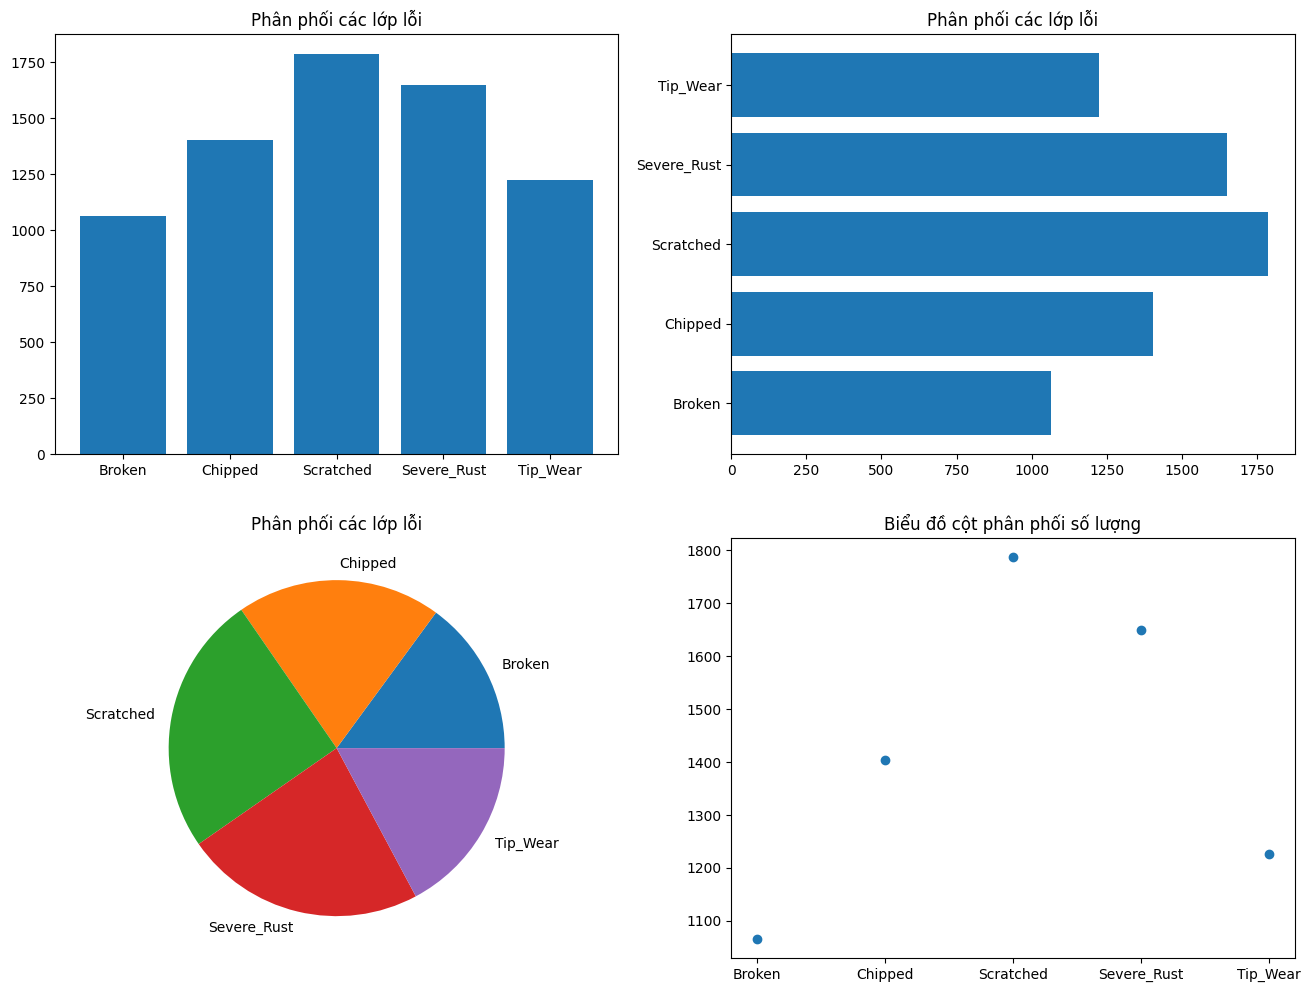

In [6]:
def visualize_class_distribution():
    names = []
    counts = []
    for class_id in range(NUM_CASSES):
        names.append(CLASS_NAMES[class_id])
        counts.append(class_counts[class_id])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0, 0].bar(names, counts)
    axes[0, 0].set_title("Phân phối các lớp lỗi")

    axes[0, 1].barh(names, counts)
    axes[0, 1].set_title("Phân phối các lớp lỗi")

    axes[1, 0].pie(counts, labels=names)
    axes[1, 0].set_title("Phân phối các lớp lỗi")

    axes[1, 1].scatter(names, counts)
    axes[1, 1].set_title("Biểu đồ cột phân phối số lượng")


    plt.show()
visualize_class_distribution()

# 5. Train Model YOLOv26

In [7]:
model = YOLO("yolo26n.pt")
results = model.train(data='data.yaml', 
                    epochs=100, 
                    imgsz=640, 
                    batch=32, 
                    workers=4, 
                    rect=True,
                    amp=True,

                    scale=0.1,
                    fliplr=0.5,
                    flipud=0.5,
                    hsv_h=0.0,
                    hsv_s=0.0,
                    hsv_v=0.2,
                    erasing=0.3,

                    lr0=0.001,
                    lrf=0.1,
                    cos_lr=True,
                    optimizer="AdamW"
                    )

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0

# 6. Visualize kết quả


📊 Training Results:
   🎯 mAP50: 0.7442
   🎯 mAP50-95: 0.4003
   🎯 Precision: 0.8000
   🎯 Recall: 0.6954
   📦 Box loss: 1.7087
   🏷️  Cls loss: 1.2315
   🎯 DFL loss: 0.0261


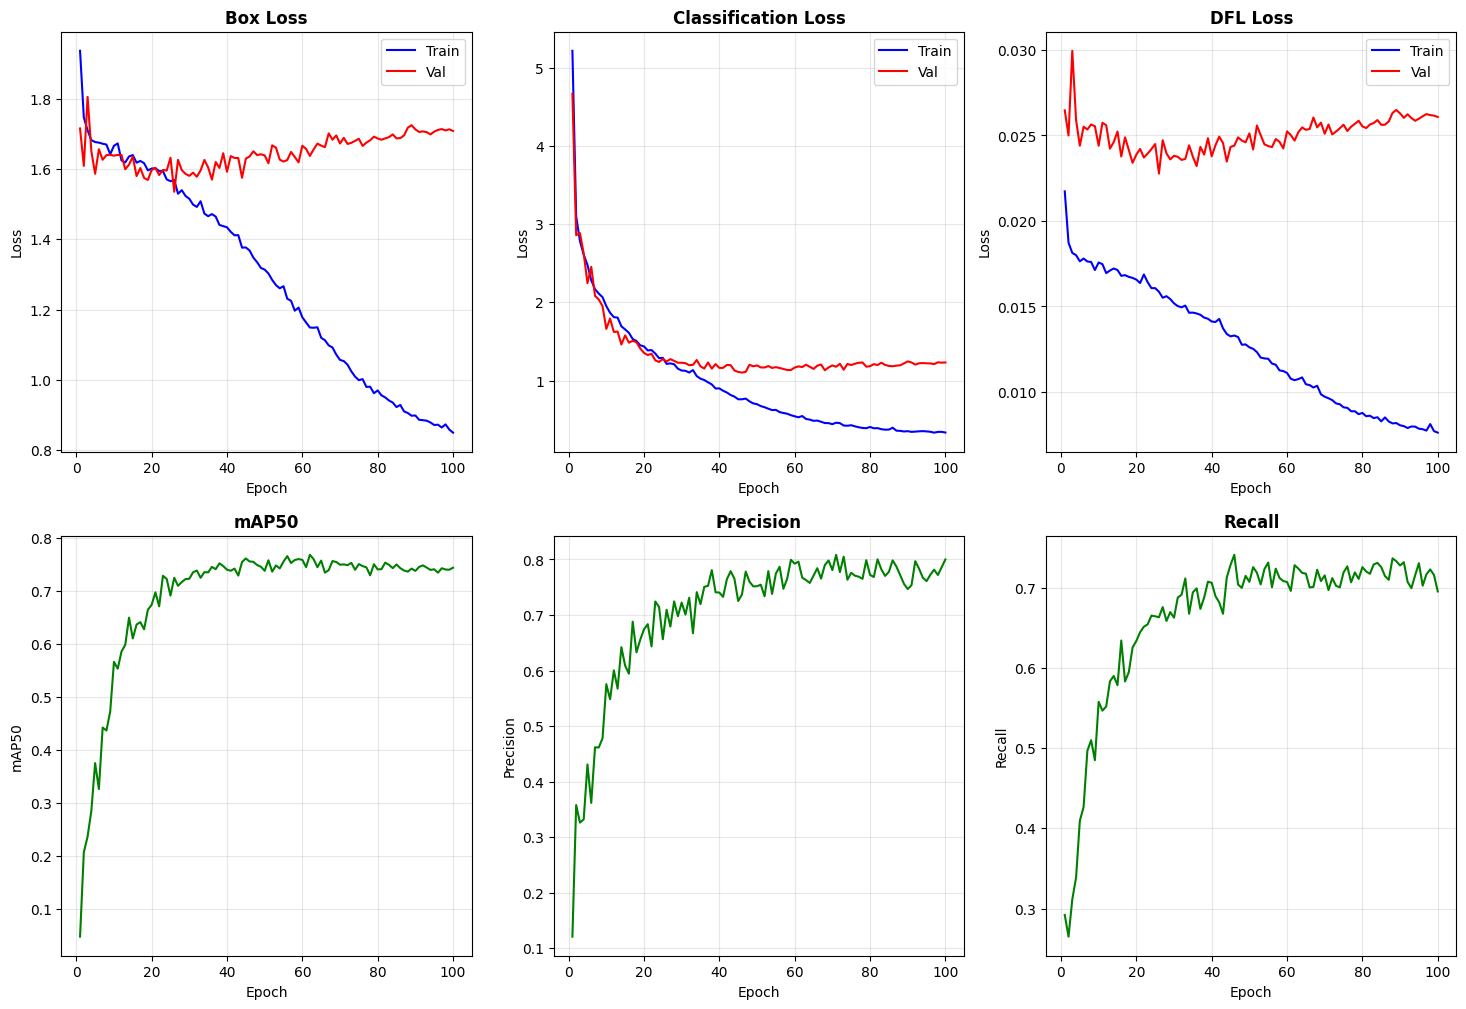

In [8]:
def visualize_training_loss(results_path):
    results_csv = Path(results_path) / "results.csv"
    df = pd.read_csv(results_csv)
    last_row = df.iloc[-1]
    final_metrics = {
            'mAP50': last_row.get('metrics/mAP50(B)', 0),
            'mAP50_95': last_row.get('metrics/mAP50-95(B)', 0),
            'precision': last_row.get('metrics/precision(B)', 0),
            'recall': last_row.get('metrics/recall(B)', 0),
            'box_loss': last_row.get('val/box_loss', 0),
            'cls_loss': last_row.get('val/cls_loss', 0),
            'dfl_loss': last_row.get('val/dfl_loss', 0)
        }
    
    # In kết quả cuối cùng
    print(f"\n📊 Training Results:")
    print(f"   🎯 mAP50: {final_metrics['mAP50']:.4f}")
    print(f"   🎯 mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"   🎯 Precision: {final_metrics['precision']:.4f}")
    print(f"   🎯 Recall: {final_metrics['recall']:.4f}")
    print(f"   📦 Box loss: {final_metrics['box_loss']:.4f}")
    print(f"   🏷️  Cls loss: {final_metrics['cls_loss']:.4f}")
    print(f"   🎯 DFL loss: {final_metrics['dfl_loss']:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    metrics = [
        ('train/box_loss', 'val/box_loss', 'Box Loss'),
        ('train/cls_loss', 'val/cls_loss', 'Classification Loss'),
        ('train/dfl_loss', 'val/dfl_loss', 'DFL Loss')
    ]
    for idx, (train_metric, val_metric, title) in enumerate(metrics):
        ax = axes[0, idx]
        if train_metric in df.columns:
            ax.plot(df['epoch'], df[train_metric], label='Train', color='blue')
        if val_metric in df.columns:
            ax.plot(df['epoch'], df[val_metric], label='Val', color='red')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    metric_plots = [
        ('metrics/mAP50(B)', 'mAP50'),
        ('metrics/precision(B)', 'Precision'),
        ('metrics/recall(B)', 'Recall')
    ]
    
    for idx, (metric, title) in enumerate(metric_plots):
        ax = axes[1, idx]
        if metric in df.columns:
            ax.plot(df['epoch'], df[metric], color='green')
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(title)
            ax.grid(True, alpha=0.3)
    plt.show()
    return final_metrics

final_metrics = visualize_training_loss('/kaggle/working/runs/detect/train')

# 7. Các biểu đồ đánh giá

--- Confusion Matrix ---


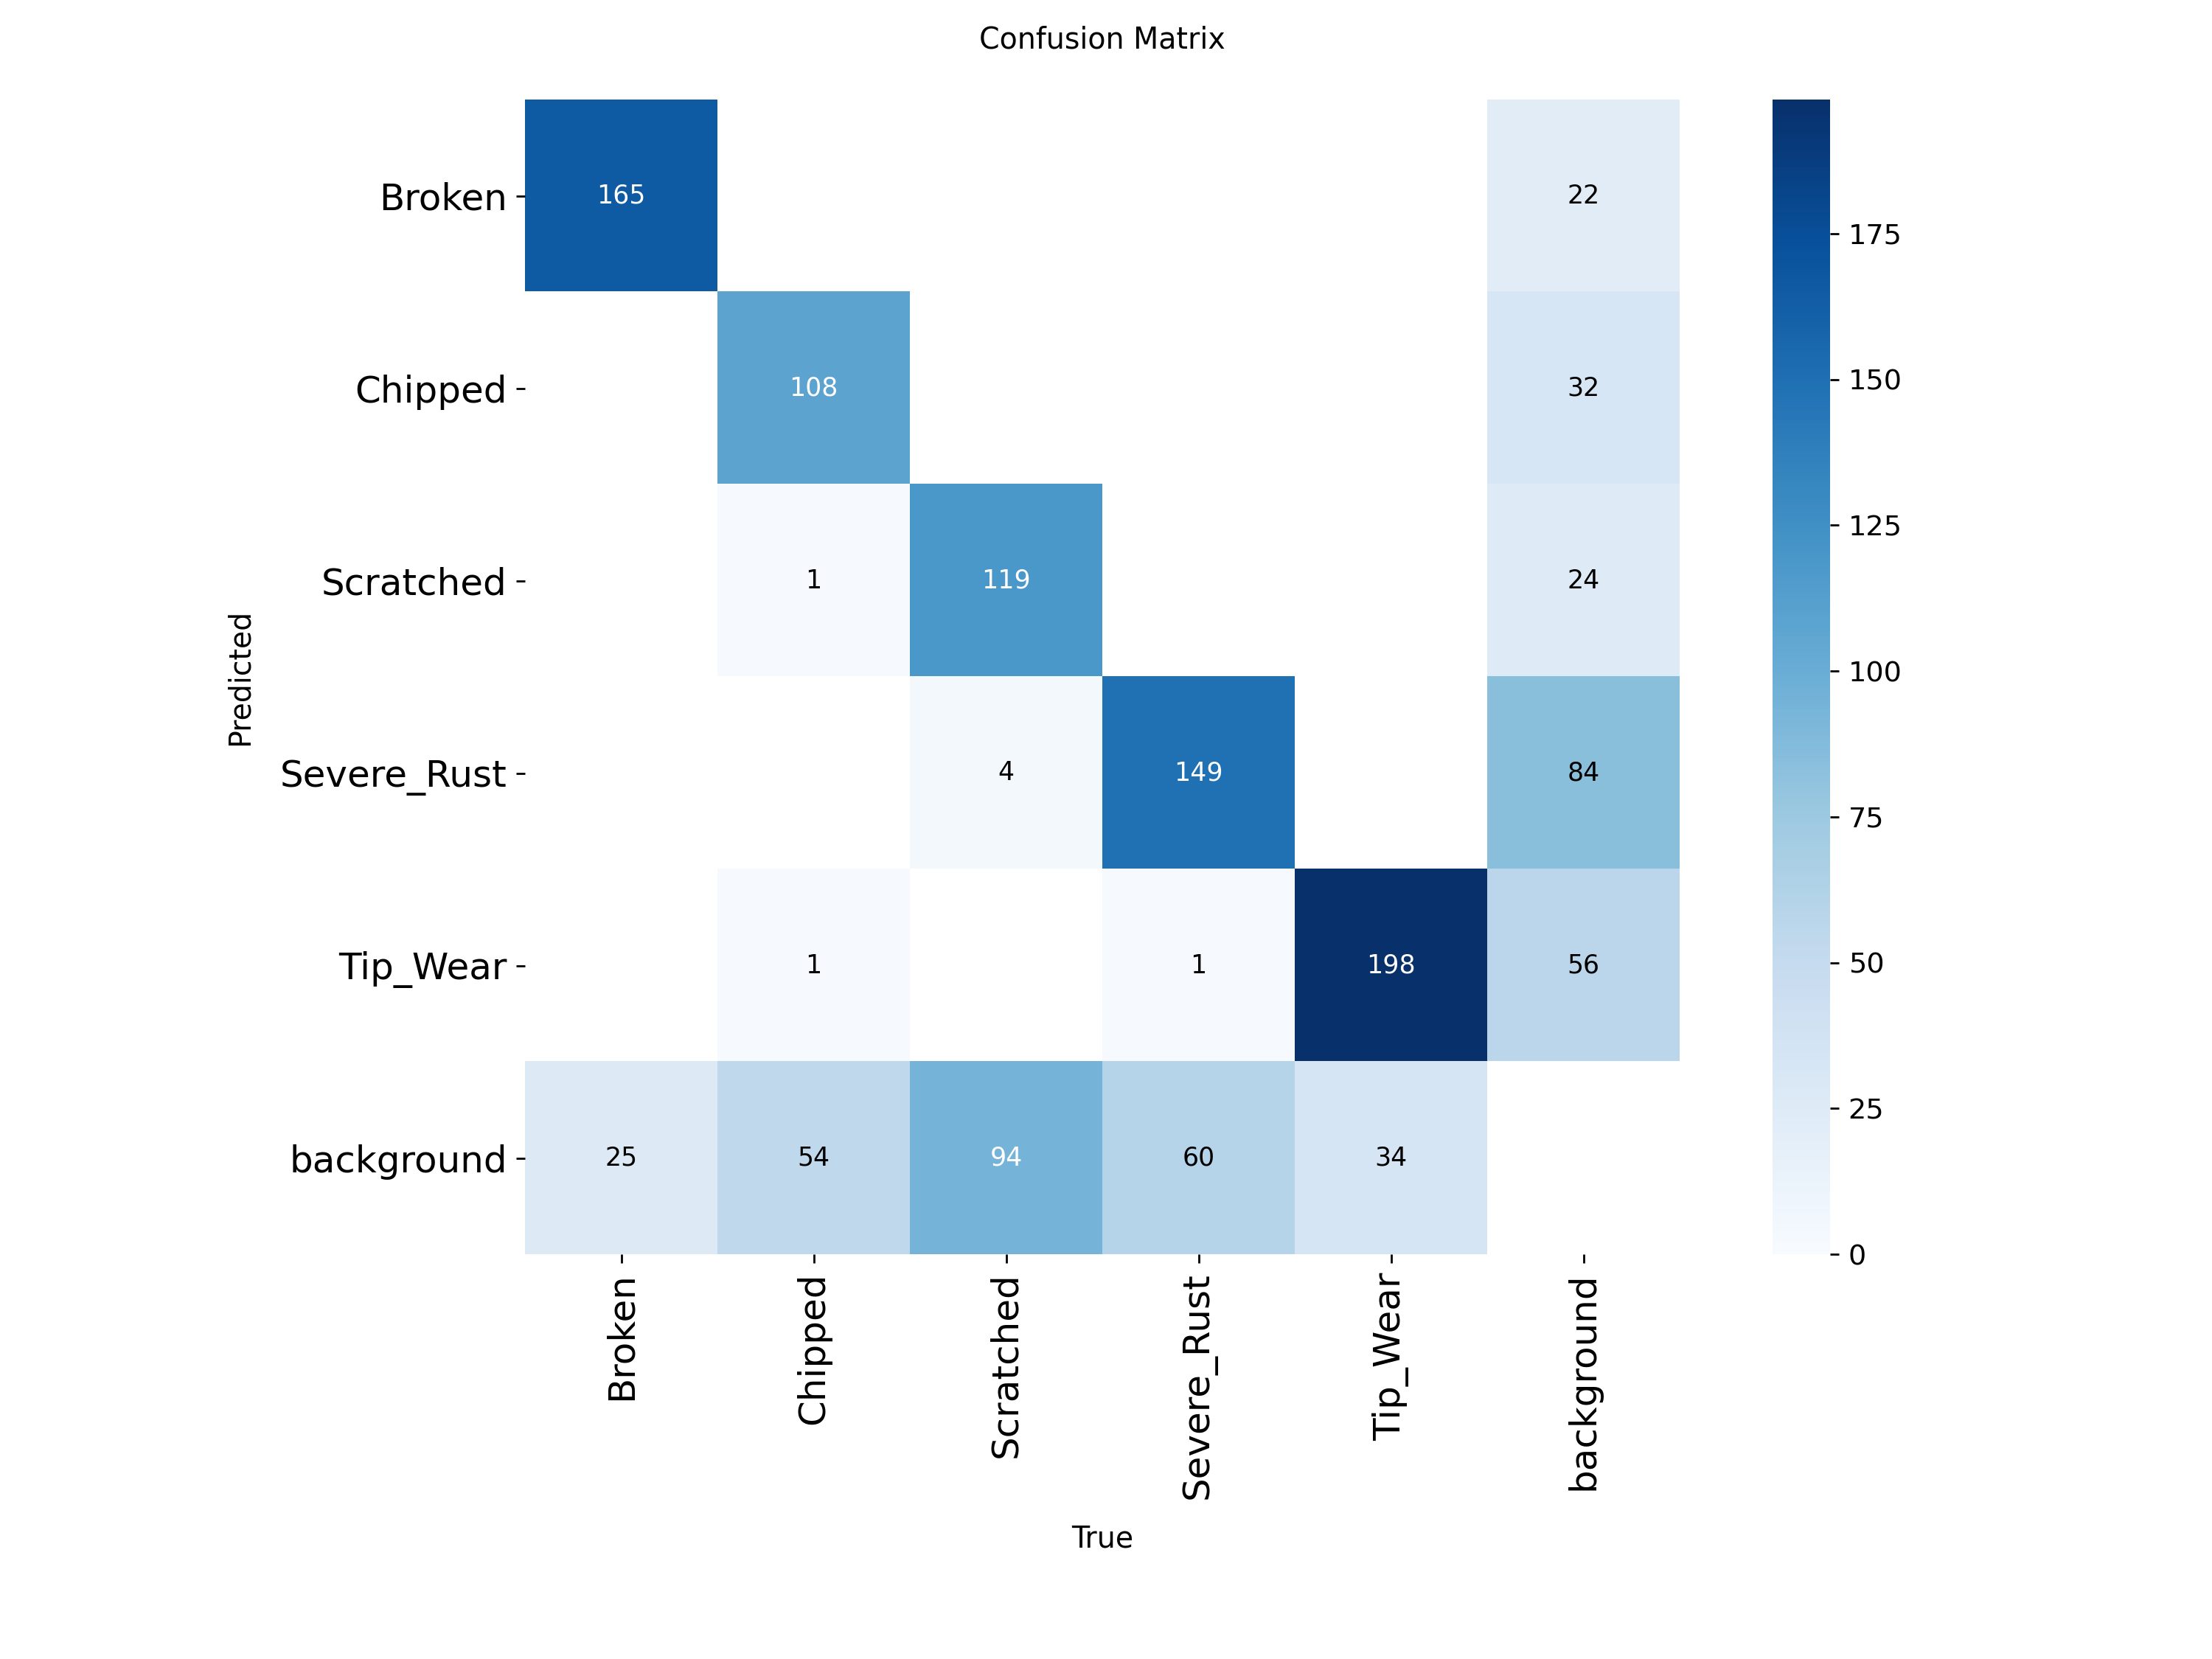

--- PR Curve ---


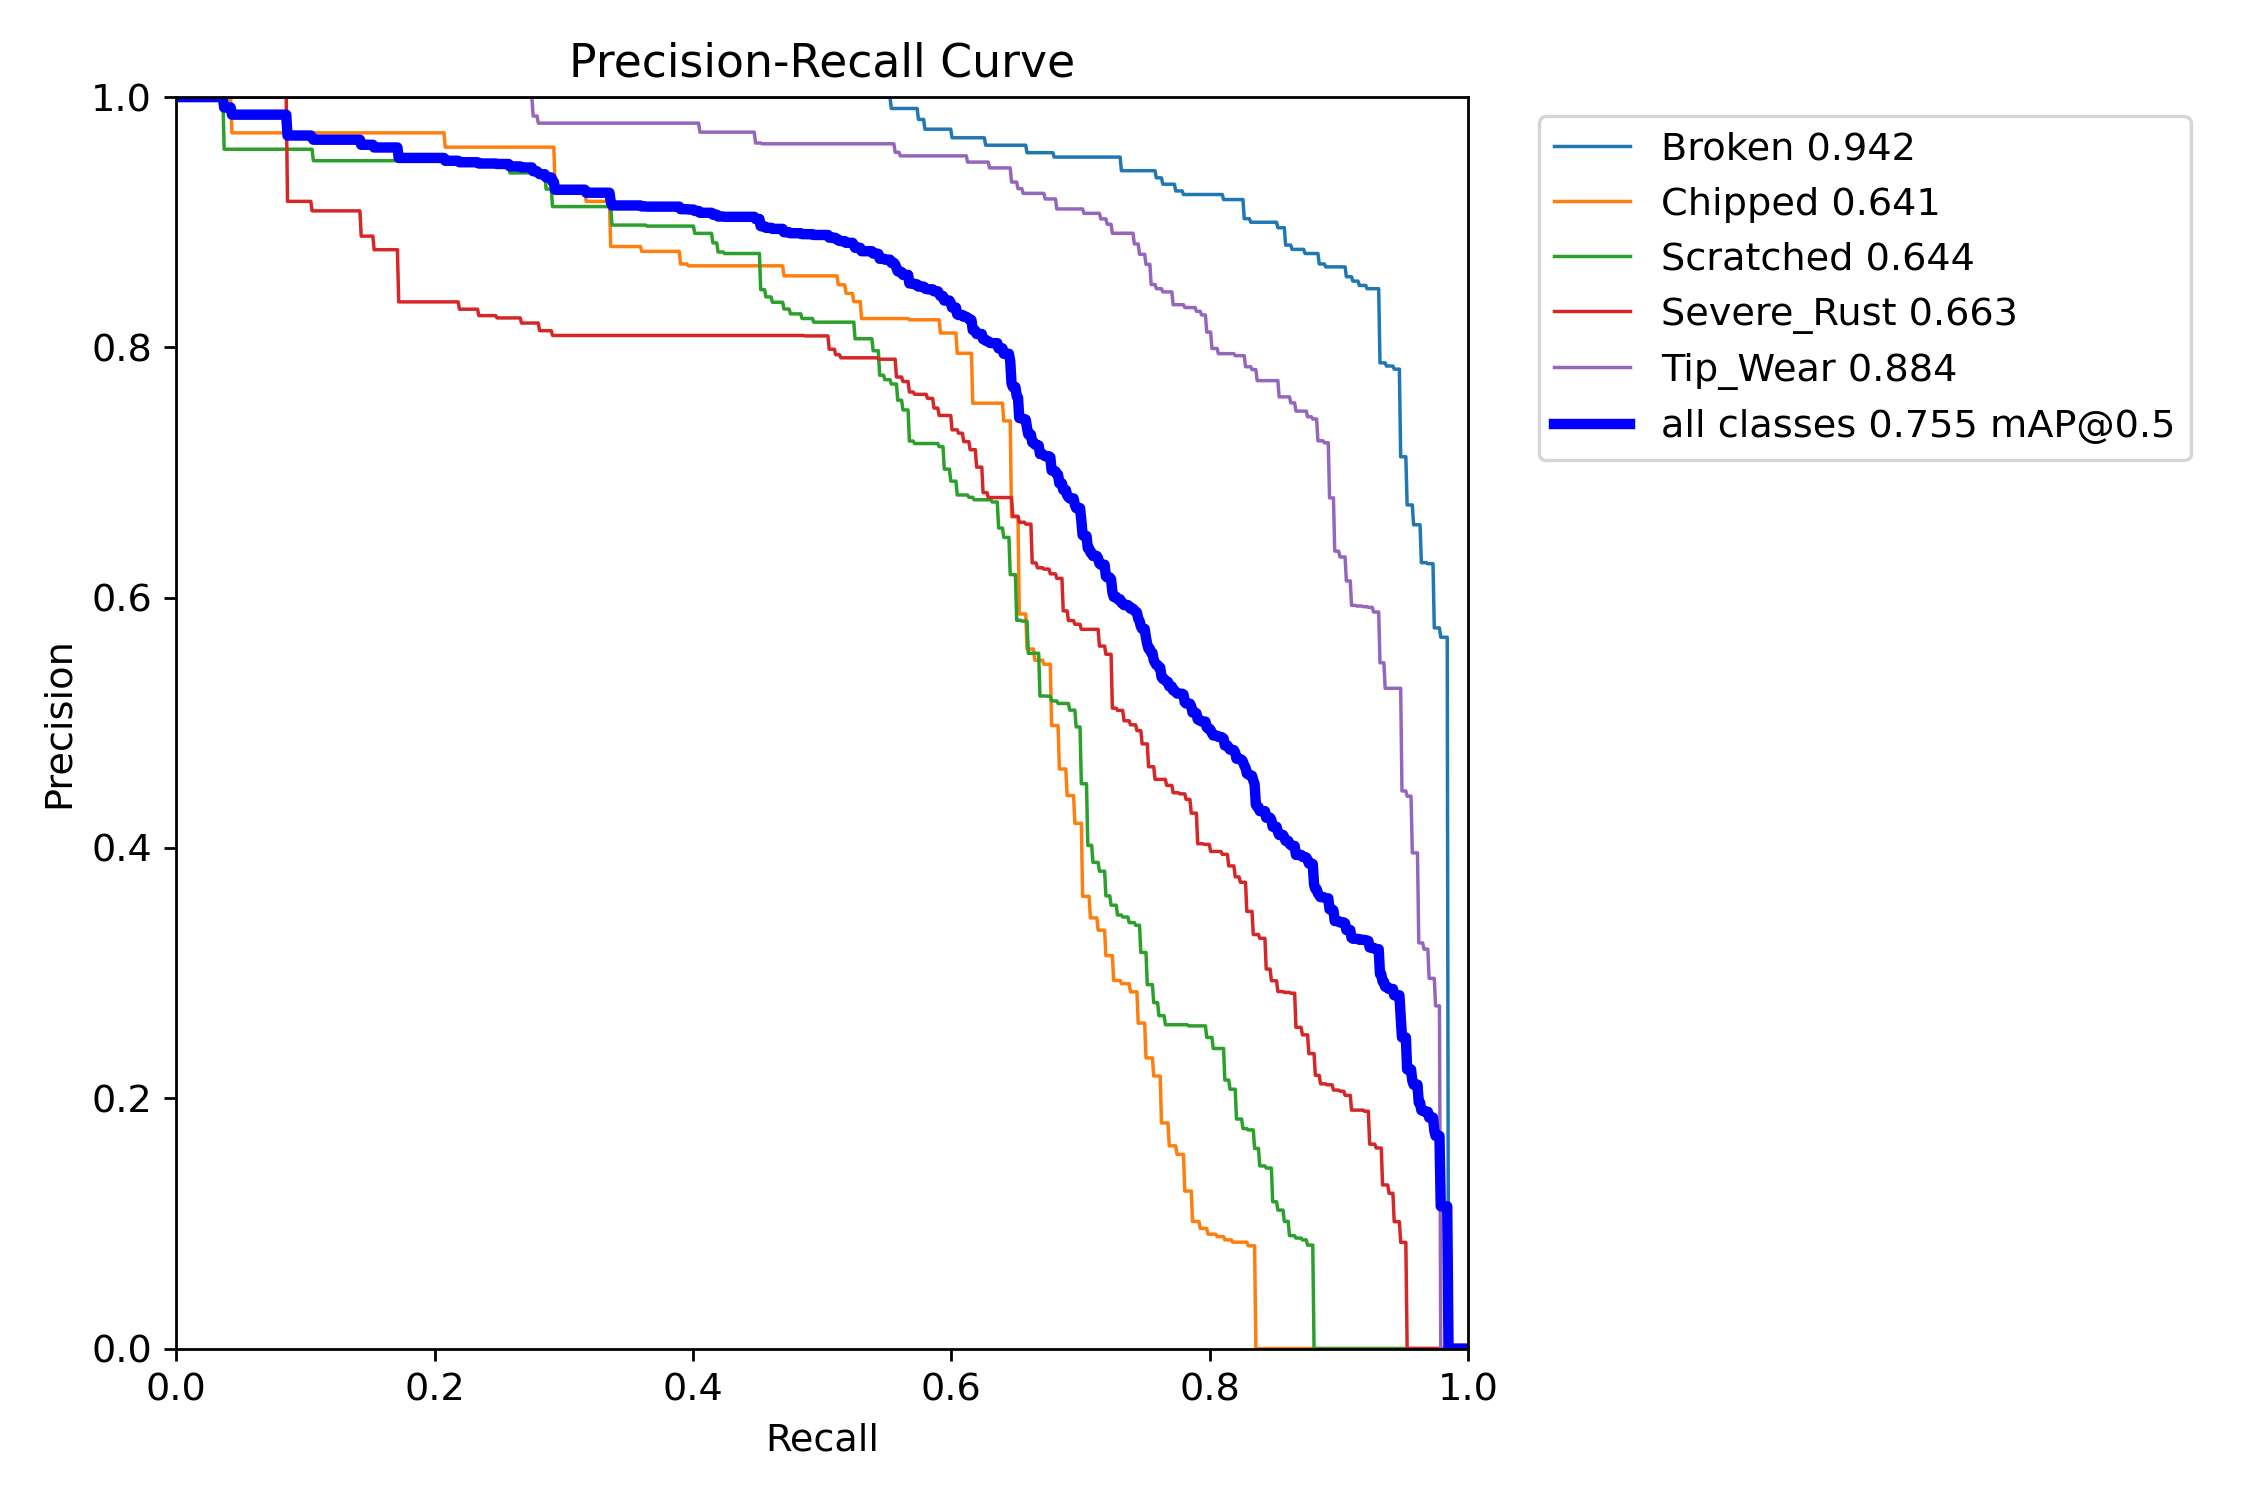

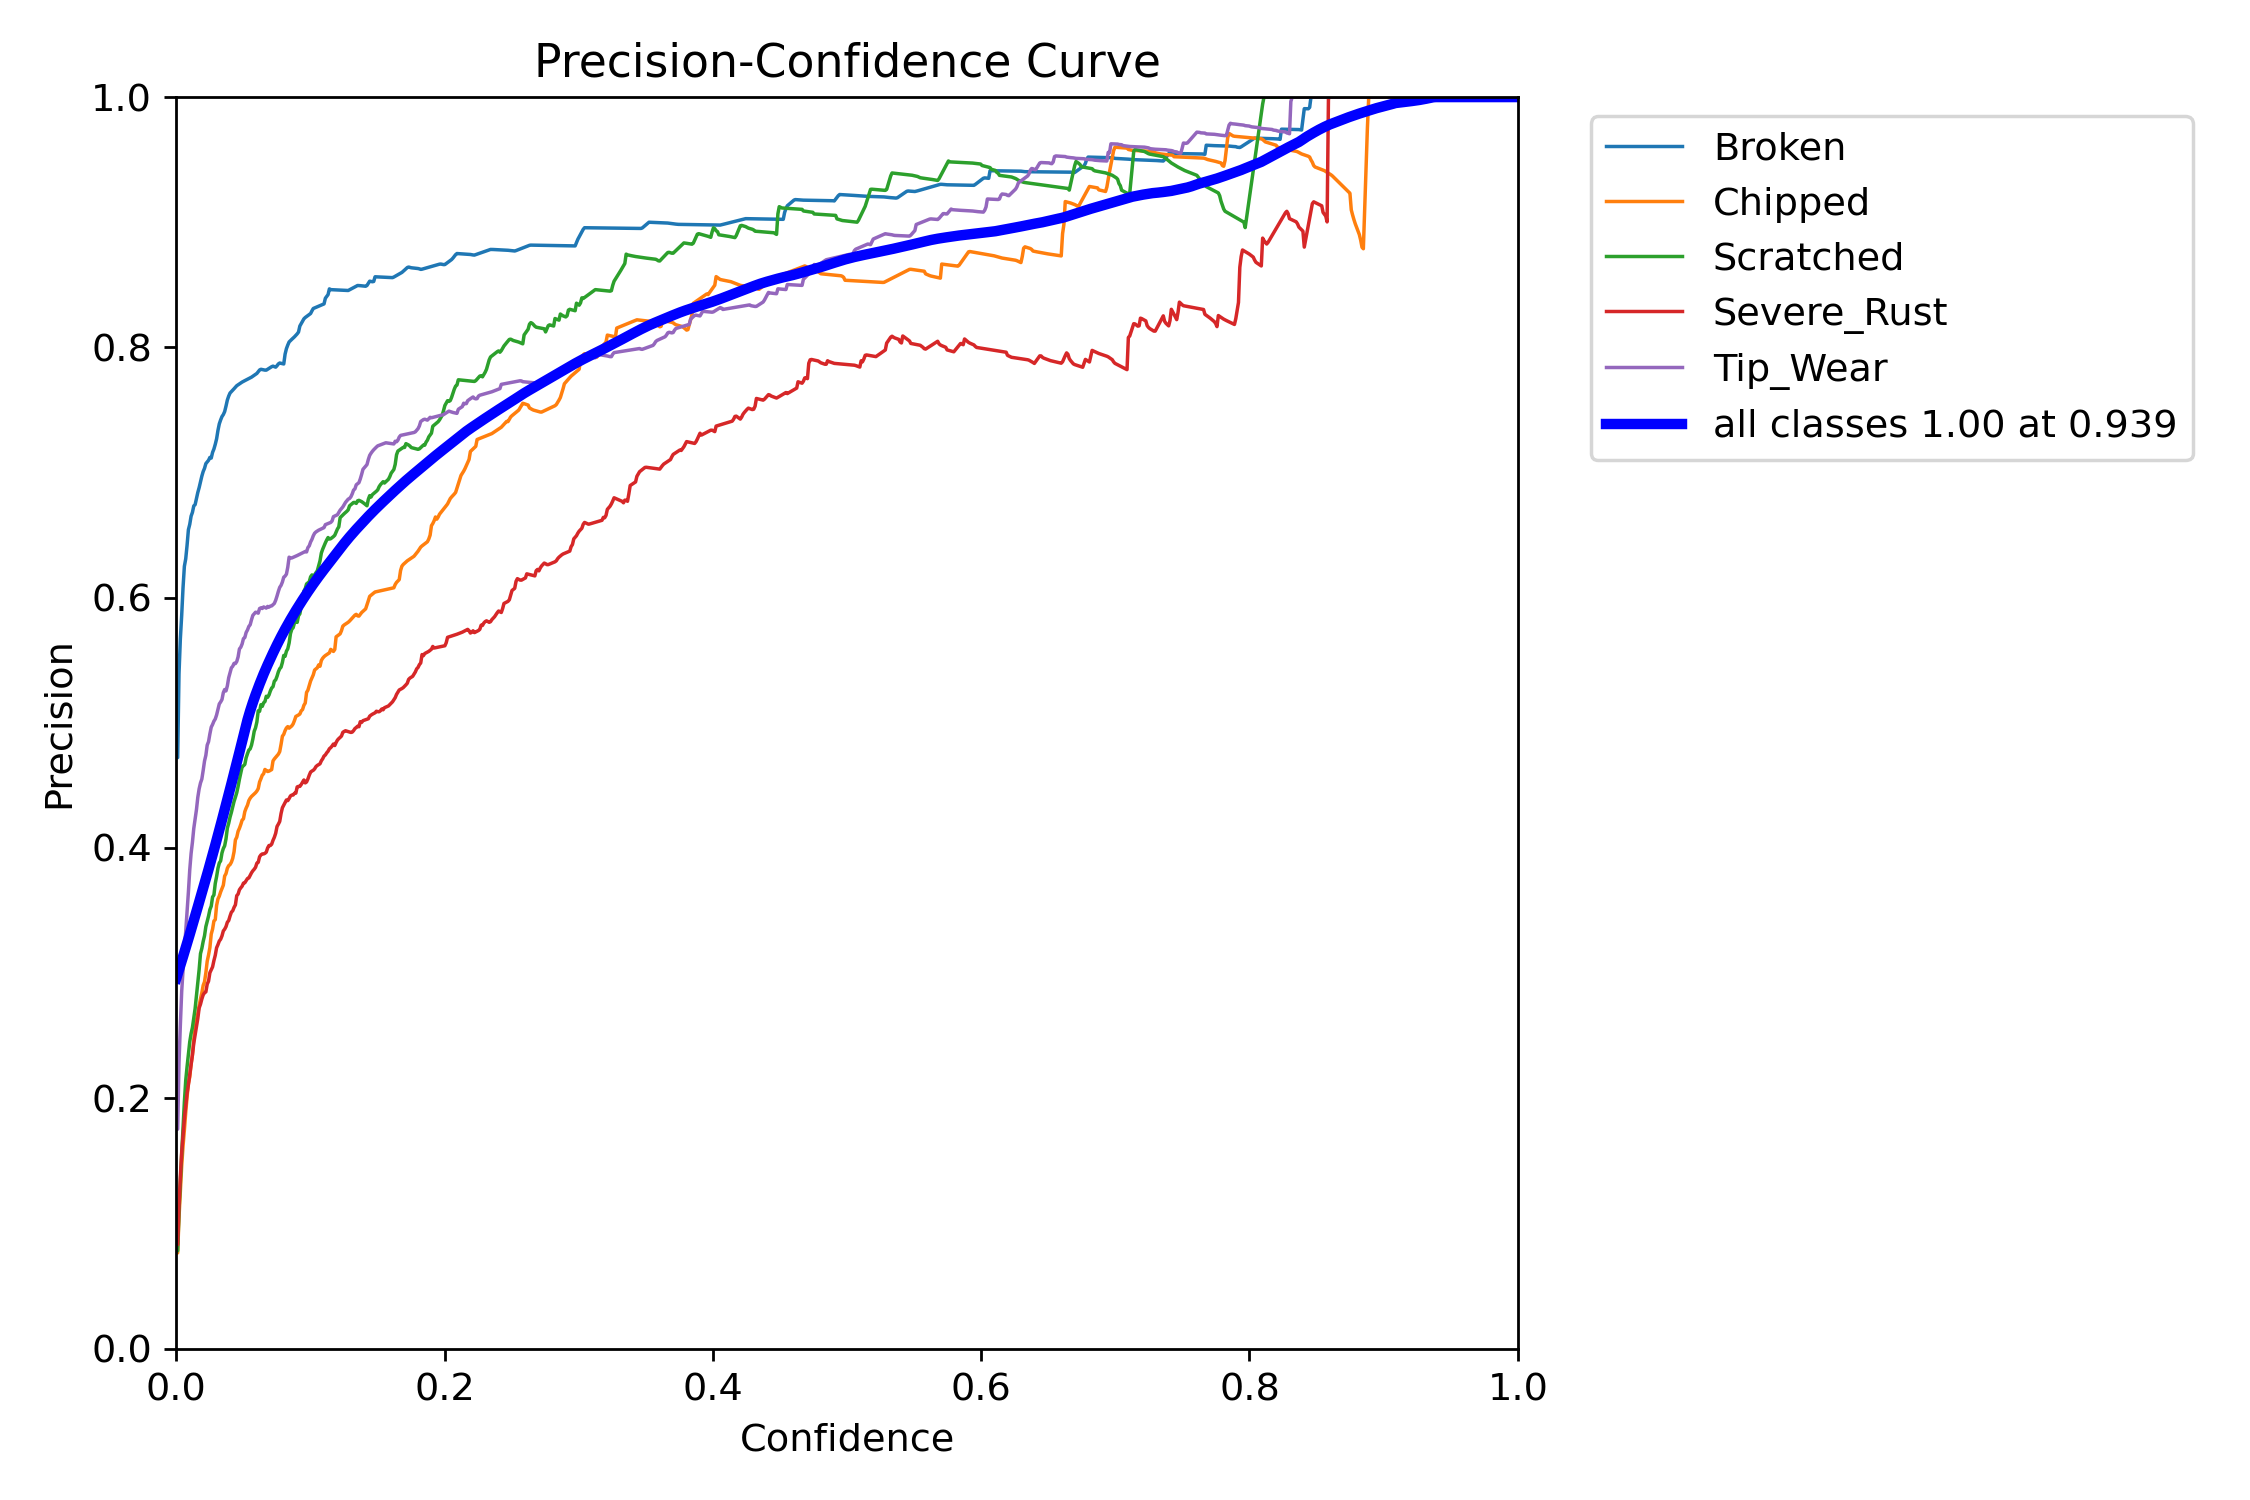

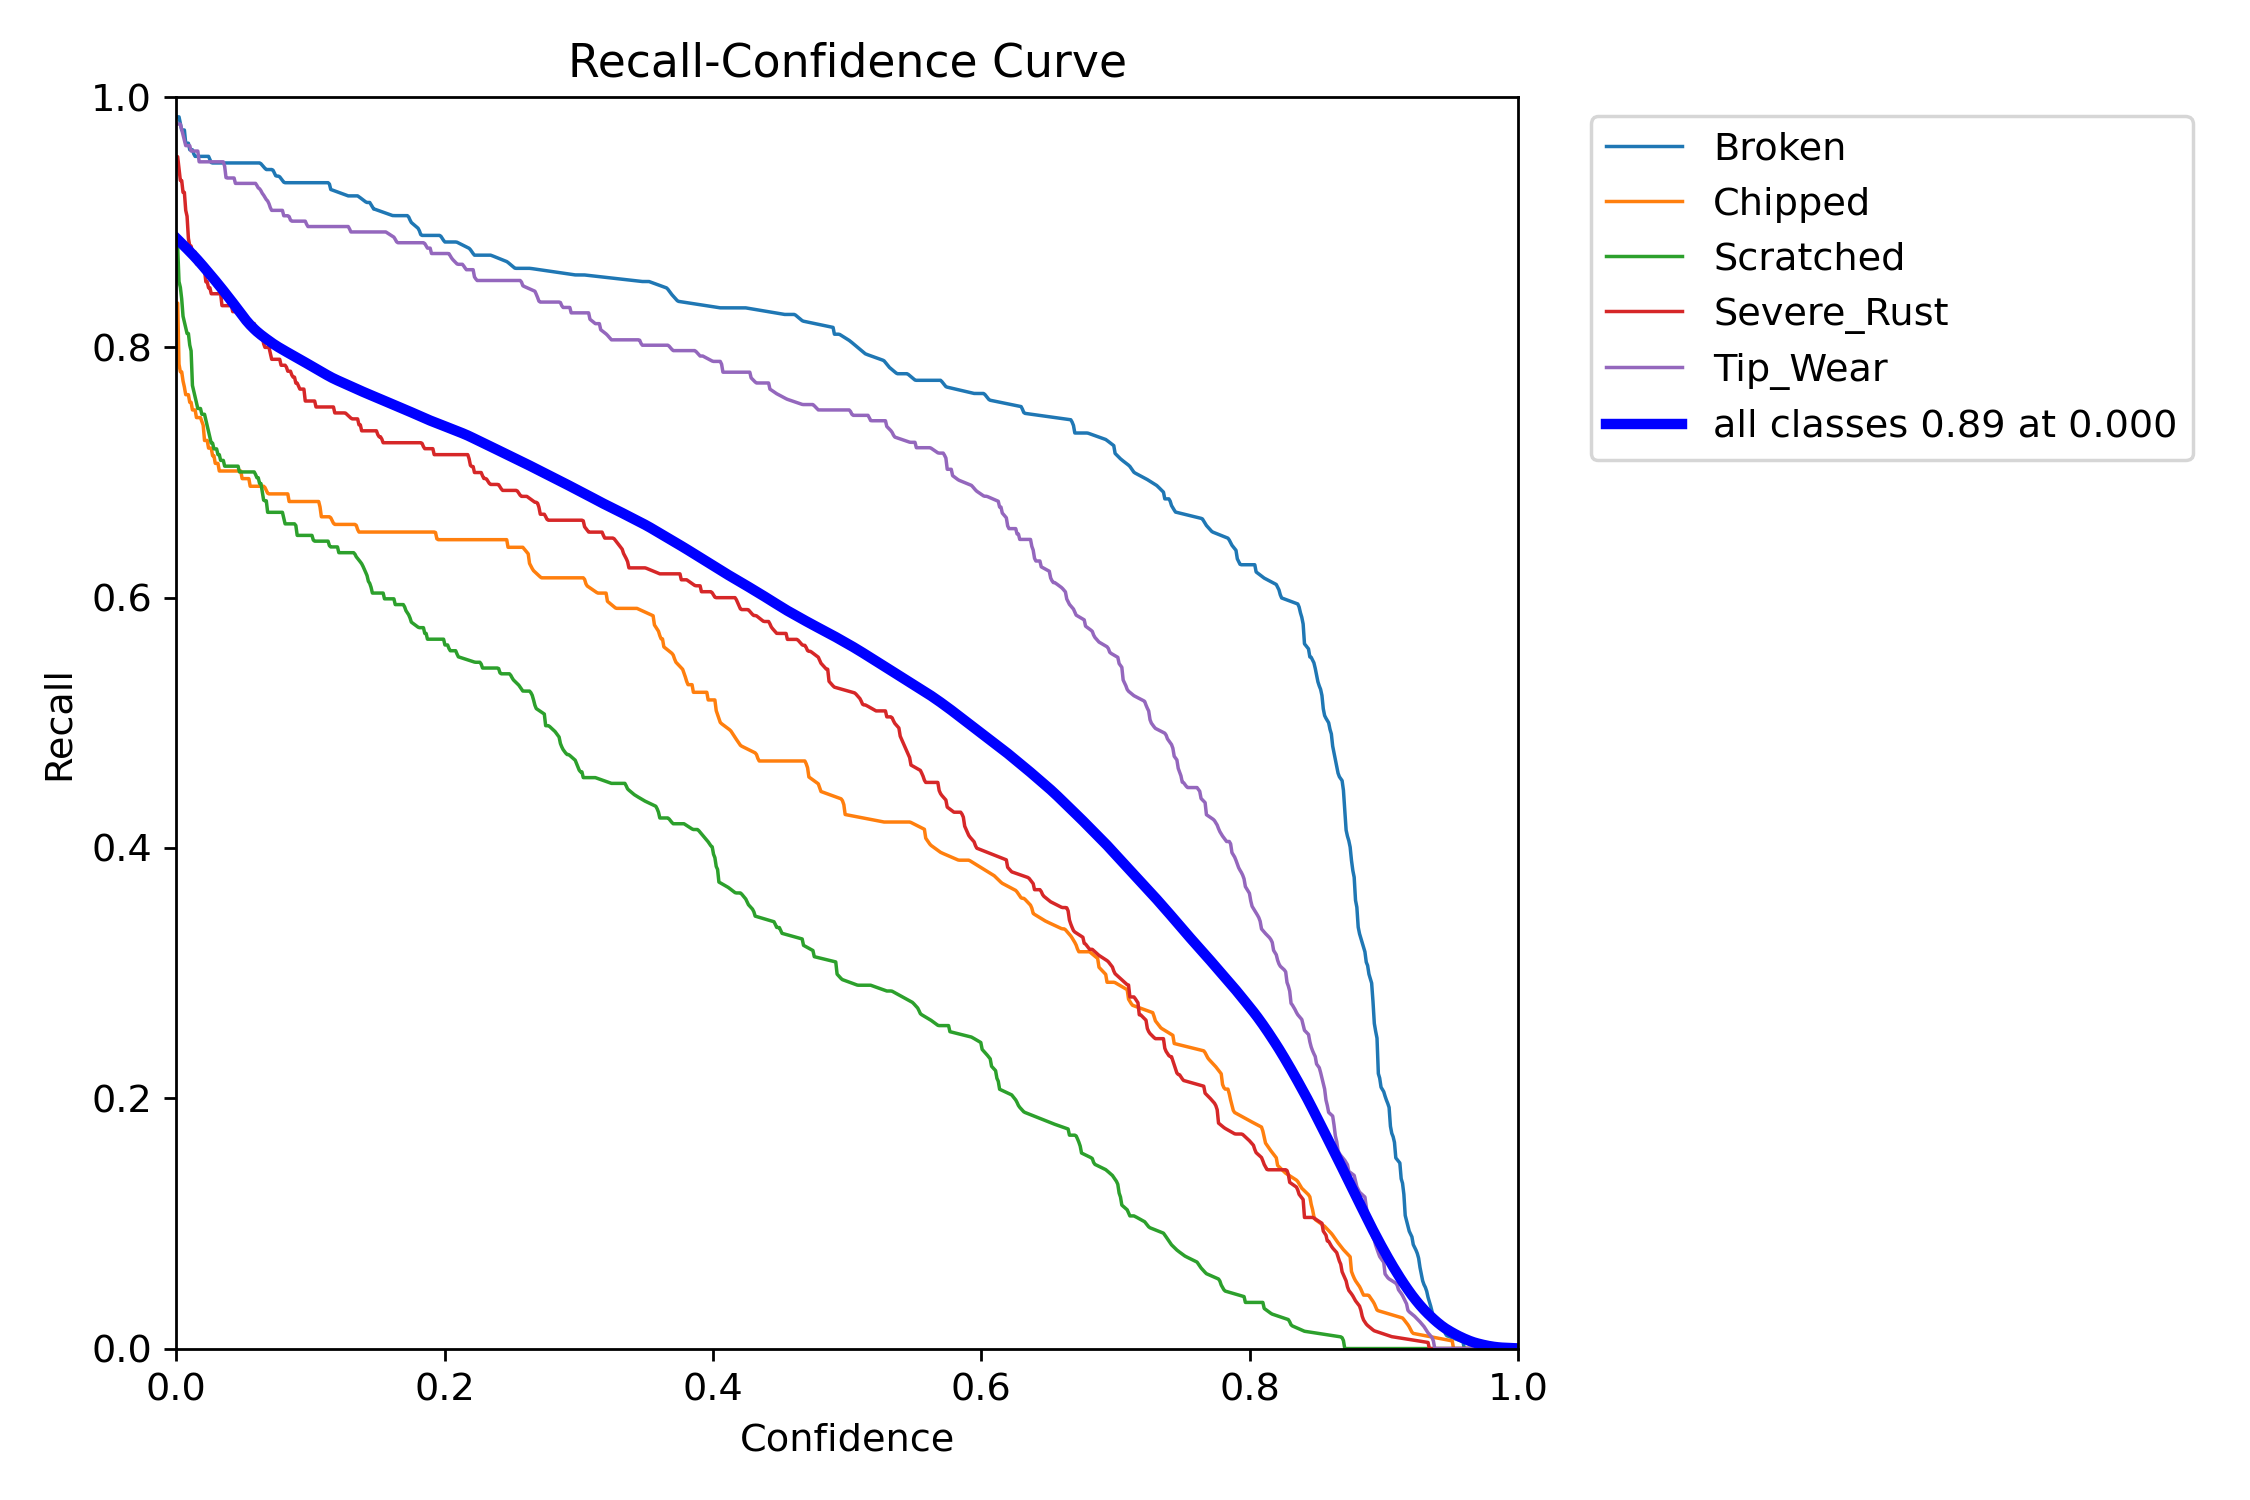

--- Loss & Metrics (Results) ---


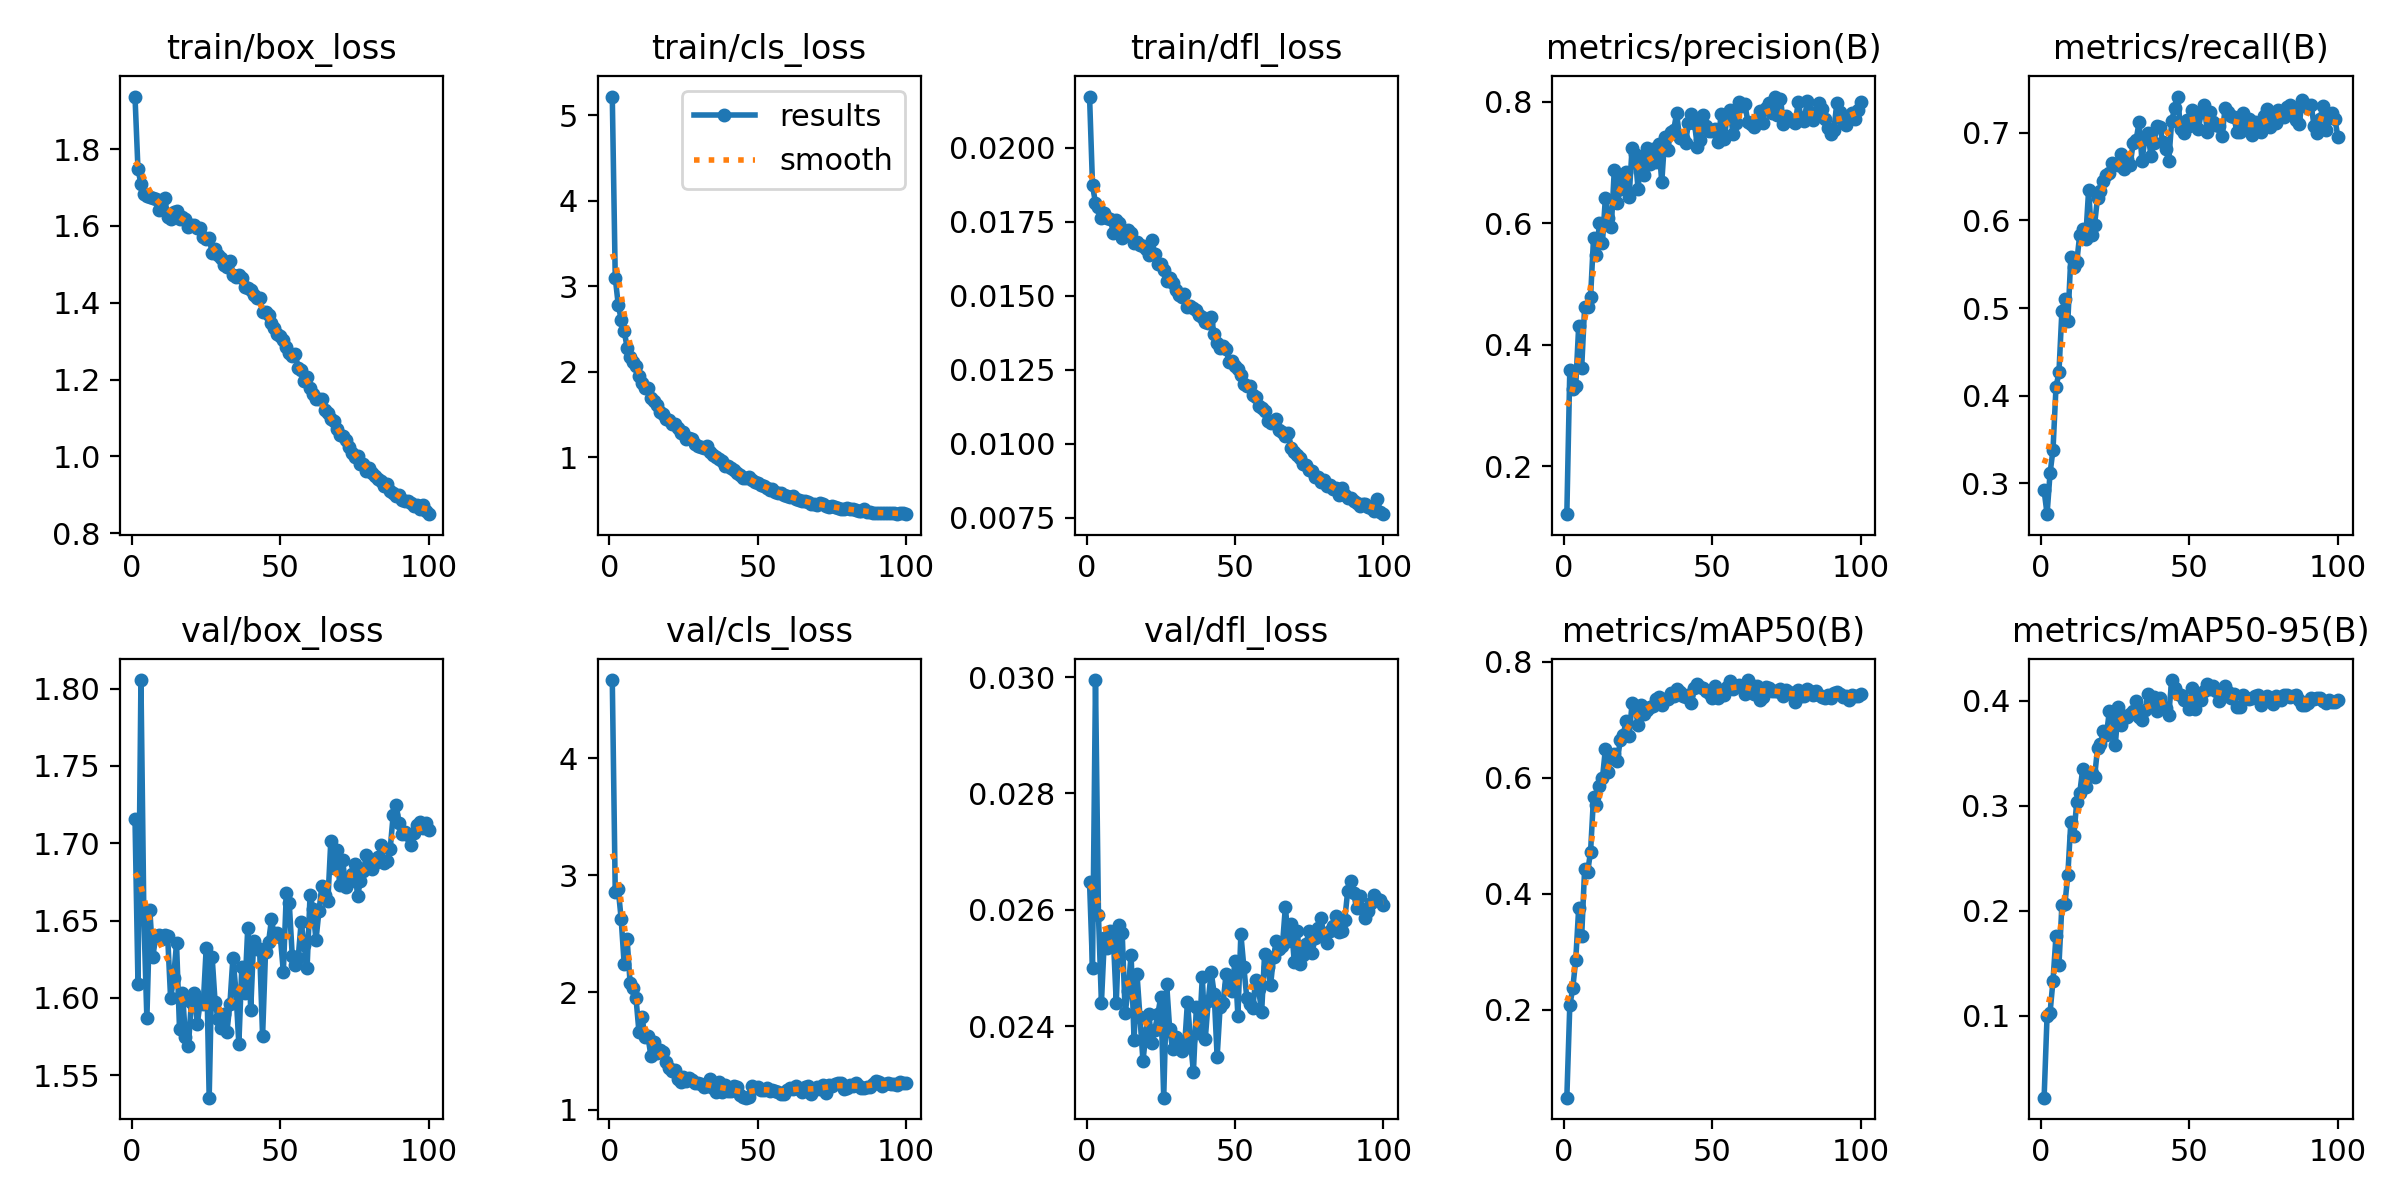

In [9]:
from IPython.display import Image, display

# Đường dẫn tới thư mục train
folder_path = '/kaggle/working/runs/detect/train/'

print("--- Confusion Matrix ---")
display(Image(filename=folder_path + 'confusion_matrix.png', width=1000))
print("--- PR Curve ---")
display(Image(filename=folder_path + 'BoxPR_curve.png', width=1000))
display(Image(filename=folder_path + 'BoxP_curve.png', width=1000))
display(Image(filename=folder_path + 'BoxR_curve.png', width=1000))

print("--- Loss & Metrics (Results) ---")
display(Image(filename=folder_path + 'results.png', width=1000))

# 8. Dự đoán

NameError: name 'NUM_CLASSES' is not defined

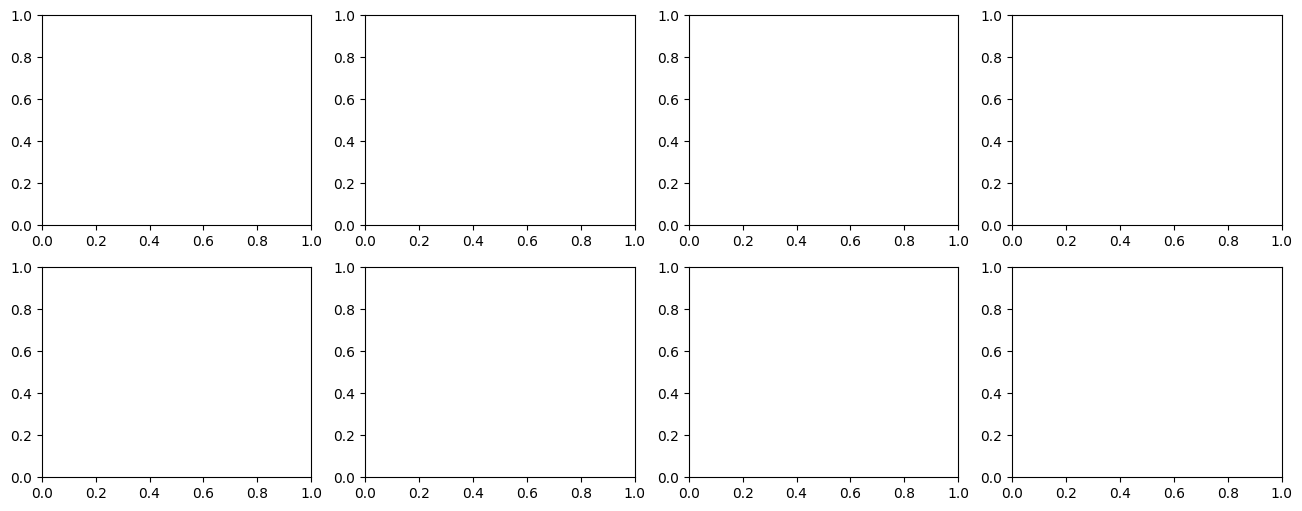

In [10]:
def predict_and_visualize(model_path, test_images_dir, num_samples=8, conf_threshold=0.5):
    model = YOLO(model_path)
    test_path = Path(test_images_dir)
    image_files = list(test_path.glob("*.jpg"))
    image_files = random.sample(image_files, min(num_samples, len(image_files)))
    NUM_CASSES=5

    cols = min(4, len(image_files))
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))

    if len(image_files) == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    total_detections = 0
    class_counts = Counter()
    confidences = []

    for idx, img_path in enumerate(image_files):
        ax = axes[idx] if len(image_files) > 1 else axes
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = model(str(img_path), conf=conf_threshold, verbose=False)
        detections = 0
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    detections += 1
                    total_detections += 1
                    
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls_id = int(box.cls[0].cpu().numpy())
                    
                    confidences.append(conf)
                    class_counts[cls_id] += 1
                    
                    # Draw bounding box
                    color = plt.cm.hsv(cls_id / NUM_CLASSES)[:3]
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add label
                    label = f"{CLASS_NAMES[cls_id]}: {conf:.2f}"
                    ax.text(x1, y1 - 5, label, 
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                            fontsize=8, color='white', fontweight='bold')
        
        ax.imshow(img_rgb)
        ax.set_title(f"{img_path.name}\n{detections} detections", fontsize=10)
        ax.axis('off')

        # Hide unused axes
    for idx in range(len(image_files), len(axes)):
        axes[idx].axis('off')
    plt.show()
    
    # Print statistics
    print(f"\n📊 Detection Summary:")
    print(f"   📷 Images: {len(image_files)}")
    print(f"   🎯 Detections: {total_detections}")
    print(f"   📈 Avg per image: {total_detections/len(image_files):.1f}")
    print(f"   📊 Avg confidence: {np.mean(confidences):.3f}" if confidences else "   📊 Avg confidence: N/A")
    print(f"   📊 Max confidence: {np.max(confidences):.3f}" if confidences else "   📊 Max confidence: N/A")
    
    print(f"\n🏷️  Class Distribution:")
    for cls_id, count in class_counts.most_common():
        print(f"   {CLASS_NAMES[cls_id]}: {count}")
    
    return {
        'total_detections': total_detections,
        'class_counts': dict(class_counts),
        'avg_confidence': np.mean(confidences) if confidences else 0
    }

prediction_results = predict_and_visualize(
    model_path='/kaggle/working/runs/detect/train/weights/best.pt',
    test_images_dir=str(DATASET_PATH / 'test' / 'Bright_Field' /'images'),
    num_samples=8,
    conf_threshold=0.5
)

In [ ]:
def predict_and_visualize(model_path, test_images_dir, num_samples=8, conf_threshold=0.5):
    model = YOLO(model_path)
    test_path = Path(test_images_dir)
    image_files = list(test_path.glob("*.jpg"))
    image_files = random.sample(image_files, min(num_samples, len(image_files)))
    NUM_CASSES=5

    cols = min(4, len(image_files))
    rows = (len(image_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))

    if len(image_files) == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    total_detections = 0
    class_counts = Counter()
    confidences = []

    for idx, img_path in enumerate(image_files):
        ax = axes[idx] if len(image_files) > 1 else axes
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = model(str(img_path), conf=conf_threshold, verbose=False)
        detections = 0
        for result in results:
            if result.boxes is not None:
                for box in result.boxes:
                    detections += 1
                    total_detections += 1
                    
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls_id = int(box.cls[0].cpu().numpy())
                    
                    confidences.append(conf)
                    class_counts[cls_id] += 1
                    
                    # Draw bounding box
                    color = plt.cm.hsv(cls_id / NUM_CLASSES)[:3]
                    rect = patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    
                    # Add label
                    label = f"{CLASS_NAMES[cls_id]}: {conf:.2f}"
                    ax.text(x1, y1 - 5, label, 
                            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                            fontsize=8, color='white', fontweight='bold')
        
        ax.imshow(img_rgb)
        ax.set_title(f"{img_path.name}\n{detections} detections", fontsize=10)
        ax.axis('off')

        # Hide unused axes
    for idx in range(len(image_files), len(axes)):
        axes[idx].axis('off')
    plt.show()
    
    # Print statistics
    print(f"\n📊 Detection Summary:")
    print(f"   📷 Images: {len(image_files)}")
    print(f"   🎯 Detections: {total_detections}")
    print(f"   📈 Avg per image: {total_detections/len(image_files):.1f}")
    print(f"   📊 Avg confidence: {np.mean(confidences):.3f}" if confidences else "   📊 Avg confidence: N/A")
    print(f"   📊 Max confidence: {np.max(confidences):.3f}" if confidences else "   📊 Max confidence: N/A")
    
    print(f"\n🏷️  Class Distribution:")
    for cls_id, count in class_counts.most_common():
        print(f"   {CLASS_NAMES[cls_id]}: {count}")
    
    return {
        'total_detections': total_detections,
        'class_counts': dict(class_counts),
        'avg_confidence': np.mean(confidences) if confidences else 0
    }

prediction_results = predict_and_visualize(
    model_path='/kaggle/working/runs/detect/train/weights/best.pt',
    test_images_dir=str(DATASET_PATH / 'test' / 'Dark_Field' /'images'),
    num_samples=8,
    conf_threshold=0.5
)

# 9. Đánh giá mô hình trên tập test

In [ ]:
# 10. ĐÁNH GIÁ MÔ HÌNH TRÊN TEST SET
# ============================================================
from ultralytics import YOLO
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')  

def evaluate_model(model):    
    # Chạy validation
    metrics = model.val(data=str(data_yaml_path), split='test')

    # 1. Lấy F1-score (thường lấy tại index của confidence threshold ~0.5)
    # metrics.box.f1 trả về mảng F1 cho mỗi class
    f1_scores = metrics.box.f1
    mean_f1 = f1_scores.mean()

    # 2. Tính toán FPS
    # speed_stats bao gồm: 'preprocess', 'inference', 'loss', 'postprocess'
    speed = metrics.speed
    latency_per_img = speed['preprocess'] + speed['inference'] + speed['postprocess']
    fps = 1000 / latency_per_img

    print(f"\n📊 Evaluation Results:")
    print(f"   🎯 Mean F1-Score: {mean_f1:.4f}")
    print(f"   ⚡ FPS: {fps:.2f} ({latency_per_img:.2f} ms/ảnh)")

    # 3. In F1 per Class
    print(f"\n📈 F1 per Class:")
    # Sử dụng metrics.names để đảm bảo mapping chính xác
    for i, class_id in enumerate(metrics.ap_class_index):
        class_name = model.names[class_id]
        print(f"   🔹 {class_name}: {f1_scores[i]:.4f}")

    return {
        "mean_f1": mean_f1,
        "fps": fps
    }
data_yaml_path='data.yaml'
evaluate_model(model)
